   bug_id            title  severity  status created_date resolved_date
0       1      Login error      High  Closed   2024-01-01    2024-01-03
1       2        UI glitch       Low    Open   2024-01-02           NaN
2       3  Crash on submit  Critical  Closed   2024-01-03    2024-01-04
3       4    Slow response    Medium  Closed   2024-01-04    2024-01-06
4       5  Payment failure      High    Open   2024-01-05           NaN

Bug Count by Severity:
 severity
High        2
Low         1
Critical    1
Medium      1
Name: count, dtype: int64


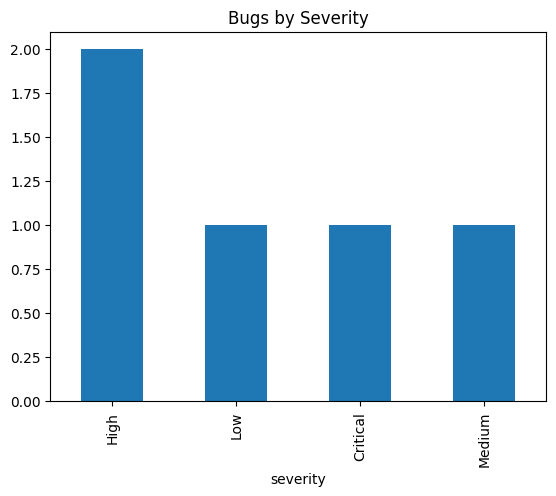


Bug Status:
 status
Closed    3
Open      2
Name: count, dtype: int64


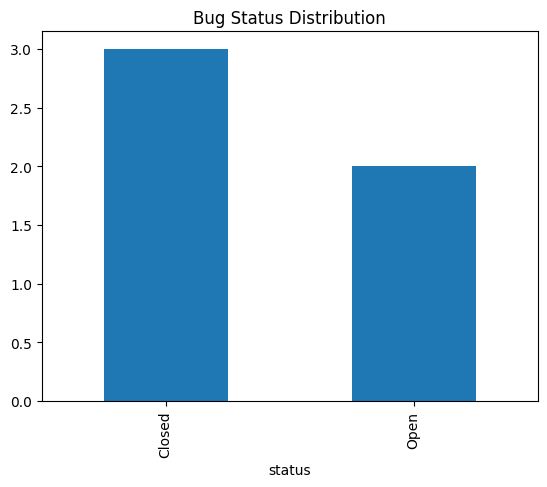


Resolution Time:
    bug_id  resolution_time
0       1              2.0
1       2              NaN
2       3              1.0
3       4              2.0
4       5              NaN


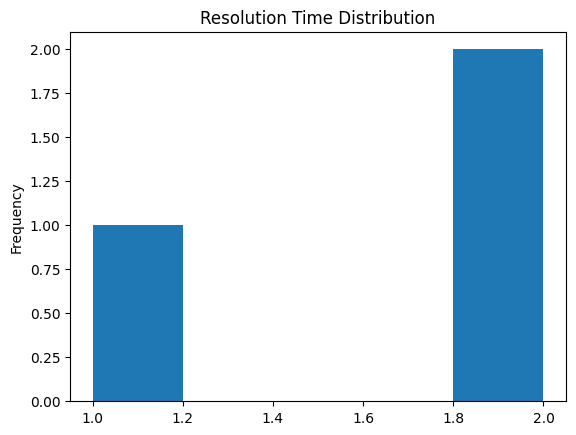


Weekly Bug Trend:
 week
2024-01-01/2024-01-07    5
Freq: W-SUN, dtype: int64


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


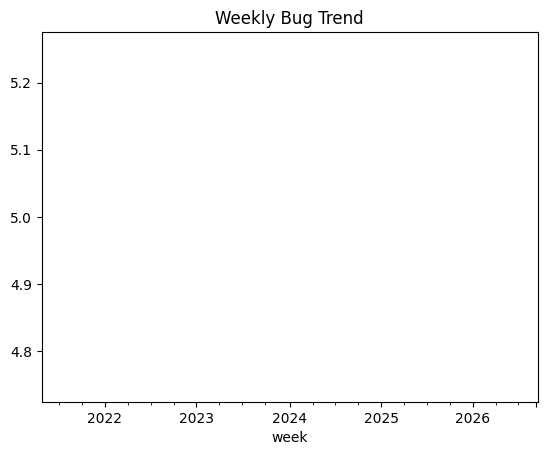

In [2]:
# Bug Tracker Analysis Project

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('bugs.csv')

# Show first few rows
print(df.head())

# Convert dates
df['created_date'] = pd.to_datetime(df['created_date'])
df['resolved_date'] = pd.to_datetime(df['resolved_date'])

# -----------------------------
# 1. Bug count by severity
# -----------------------------
severity_count = df['severity'].value_counts()
print("\nBug Count by Severity:\n", severity_count)

severity_count.plot(kind='bar', title='Bugs by Severity')
plt.show()

# -----------------------------
# 2. Bug status count
# -----------------------------
status_count = df['status'].value_counts()
print("\nBug Status:\n", status_count)

status_count.plot(kind='bar', title='Bug Status Distribution')
plt.show()

# -----------------------------
# 3. Resolution time
# -----------------------------
df['resolution_time'] = (df['resolved_date'] - df['created_date']).dt.days

print("\nResolution Time:\n", df[['bug_id', 'resolution_time']])

df['resolution_time'].dropna().plot(kind='hist', bins=5, title='Resolution Time Distribution')
plt.show()

# -----------------------------
# 4. Weekly bug trend
# -----------------------------
df['week'] = df['created_date'].dt.to_period('W')
weekly_bugs = df.groupby('week').size()

print("\nWeekly Bug Trend:\n", weekly_bugs)

weekly_bugs.plot(kind='line', title='Weekly Bug Trend')
plt.show()